## Exercise - Analyzing data Science job demand



In [7]:
# Importing Libraries
import pandas as pd                              # Pandas: work with and analyze tabular data
from datasets import load_dataset               # Hugging Face: load the job postings dataset
import matplotlib.pyplot as plt                 # Matplotlib: create charts and visualizations


# Loading Data
dataset = load_dataset('lukebarousse/data_jobs') # Download/load Luke's job dataset
df = dataset['train'].to_pandas()                # Convert the dataset into a Pandas DataFrame


# Data Cleanup
df['job_posted_date'] = pd.to_datetime(
    df['job_posted_date']
)  

In [8]:
# Filter the main DataFrame to only keep rows from the United States
# This uses boolean indexing to select matching rows
df_US = df[df['job_country'] == 'United States']

In [9]:
# Convert the job posting date to the full month name
# strftime('%B') extracts the month as a readable string
df_US['job_posted_month'] = df_US['job_posted_date'].dt.strftime('%B')

# Display the updated DataFrame with the new month column
df_US

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN,June
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',...",July
5,Data Engineer,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,Georgia,2023-11-07 14:01:59,False,False,United States,NaN,NaN,NaN,smart folks inc,"['python', 'sql', 'gcp']","{'cloud': ['gcp'], 'programming': ['python', '...",November
6,Senior Data Engineer,Senior Data Engineer - GCP Cloud,"Dearborn, MI",via LinkedIn,Full-time,False,"Florida, United States",2023-03-27 13:18:18,False,False,United States,NaN,NaN,NaN,"Miracle Software Systems, Inc","['sql', 'python', 'java', 'sql server', 'gcp',...","{'cloud': ['gcp', 'bigquery'], 'databases': ['...",March
9,Data Scientist,Data Scientist II,Anywhere,via ZipRecruiter,Full-time,True,"New York, United States",2023-04-23 13:02:57,False,False,United States,NaN,NaN,NaN,"Radwell International, LLC","['sql', 'python', 'r', 'mongodb', 'mongodb', '...","{'analyst_tools': ['excel'], 'cloud': ['azure'...",April
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785673,Data Scientist,Asset Management Data Scientist,"New York, NY",via Trabajo.org,Full-time,False,"New York, United States",2023-10-16 06:01:53,True,False,United States,NaN,NaN,NaN,JPMorgan Chase & Co.,NaN,NaN,October
785685,Data Analyst,Data Analyst,"Indianapolis, IN",via Trabajo.org,Full-time,False,"Illinois, United States",2023-07-16 06:01:27,True,False,United States,NaN,NaN,NaN,"Aara Technologies, Inc","['sql', 'excel']","{'analyst_tools': ['excel'], 'programming': ['...",July
785692,Data Scientist,Data Scientist- Hybrid Work Location,"Dayton, OH",via Ai-Jobs.net,Full-time,False,"Illinois, United States",2023-04-21 06:02:31,False,True,United States,year,157500.0,NaN,Tenet3,"['python', 'matlab', 'r']","{'programming': ['python', 'matlab', 'r']}",April
785703,Data Analyst,Data Analyst - CRYPTOGRAPHY - Full-time,Anywhere,via Snagajob,Full-time,True,"Texas, United States",2023-01-28 06:02:55,True,False,United States,NaN,NaN,NaN,Axelon Services Corporation,NaN,NaN,January


In [10]:
# Create a month-based column using the same date formatting logic
# This is useful when comparing posting patterns across the full dataset
df['job_posted_country'] = df_US['job_posted_date'].dt.strftime('%B')

In [11]:
# Create a pivot table to count job postings by month and job title
# index groups rows by month, columns separate job titles, and size counts occurrences
df_US_pivot = df_US.pivot_table(index='job_posted_month', columns='job_title_short', aggfunc='size')

In [ ]:
# Reset the index so 'job_posted_month' becomes a normal column again
df_US_pivot.reset_index(inplace=True)  # inplace=True modifies the existing DataFrame directly


# Convert month names (January, February, etc.) into month numbers (1, 2, etc.)
df_US_pivot['month_no'] = pd.to_datetime(
    df_US_pivot['job_posted_month'],   # Take the month-name column
    format='%B'                        # %B tells Pandas these are full month names
).dt.month                             # Extract the numerical month: January = 1, February = 2, etc.


# Sort the rows using the month numbers so months are in chronological order
df_US_pivot.sort_values('month_no', inplace=True)  # Sort January (1) → December (12)


# Make 'job_posted_month' the index again
df_US_pivot.set_index('job_posted_month', inplace=True)  # Month names become the row labels/index


# Remove the temporary month number column because we no longer need it
df_US_pivot.drop(columns='month_no', inplace=True)  # Delete helper column after sorting


# Display the finished pivot table
df_US_pivot

<Axes: xlabel='job_posted_month'>

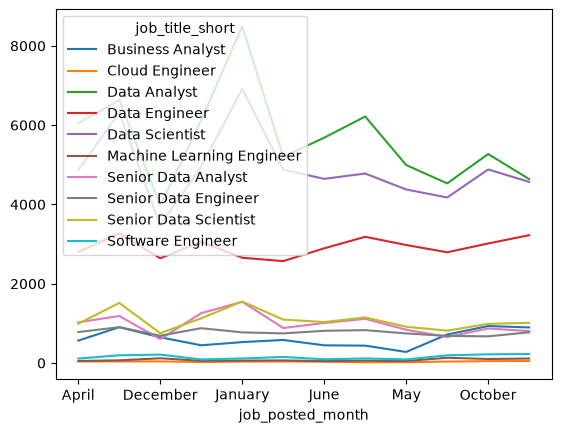

In [12]:
df_US_pivot.plot(kind='line')

<Axes: xlabel='job_posted_month'>

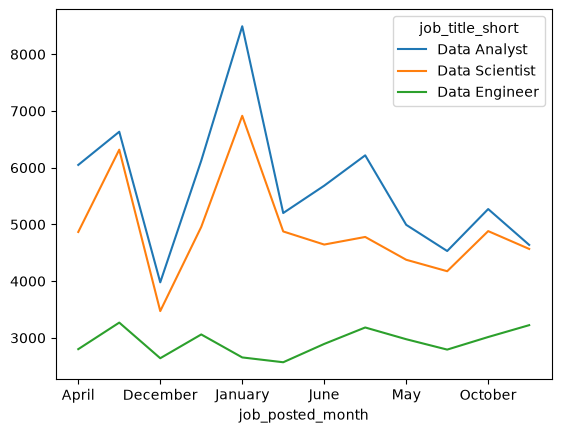

In [15]:
# Find the 3 most common job titles in the US dataset
top_3 = df_US['job_title_short'].value_counts().head(3)  # Count job titles and keep the top 3

# Convert the top 3 job-title labels from the index into a normal Python list
top_3 = top_3.index.tolist()  # Example: ['Data Analyst', 'Data Scientist', 'Data Engineer']


# Select only those top 3 job-title columns from the pivot table
# Then plot their monthly trends as a line chart
df_US_pivot[top_3].plot(kind='line')

TypeError: 'DataFrame' object is not callable